In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [14]:
df = pd.read_csv("Unemployment in India.csv")

print(df.head())
print(df.shape)
print(df.info())

           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019    Monthly                              3.65   
1  Andhra Pradesh   30-06-2019    Monthly                              3.05   
2  Andhra Pradesh   31-07-2019    Monthly                              3.75   
3  Andhra Pradesh   31-08-2019    Monthly                              3.32   
4  Andhra Pradesh   30-09-2019    Monthly                              5.17   

    Estimated Employed   Estimated Labour Participation Rate (%)   Area  
0           11999139.0                                     43.24  Rural  
1           11755881.0                                     42.05  Rural  
2           12086707.0                                     43.50  Rural  
3           12285693.0                                     43.97  Rural  
4           12256762.0                                     44.68  Rural  
(768, 7)
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data column

In [15]:
df.columns = df.columns.str.strip()

print(df.columns)

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='str')


In [16]:
print(df.isnull().sum())

Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64


In [17]:
df.dropna(inplace=True)

print(df.isnull().sum())

Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64


In [18]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

print(df["Date"].head())

0   2019-05-31
1   2019-06-30
2   2019-07-31
3   2019-08-31
4   2019-09-30
Name: Date, dtype: datetime64[us]


In [19]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.strftime("%b")

print(df.head())

           Region       Date Frequency  Estimated Unemployment Rate (%)  \
0  Andhra Pradesh 2019-05-31   Monthly                             3.65   
1  Andhra Pradesh 2019-06-30   Monthly                             3.05   
2  Andhra Pradesh 2019-07-31   Monthly                             3.75   
3  Andhra Pradesh 2019-08-31   Monthly                             3.32   
4  Andhra Pradesh 2019-09-30   Monthly                             5.17   

   Estimated Employed  Estimated Labour Participation Rate (%)   Area  Year  \
0          11999139.0                                    43.24  Rural  2019   
1          11755881.0                                    42.05  Rural  2019   
2          12086707.0                                    43.50  Rural  2019   
3          12285693.0                                    43.97  Rural  2019   
4          12256762.0                                    44.68  Rural  2019   

   Month Month_Name  
0      5        May  
1      6        Jun  
2      7

In [20]:
print(df.describe())

                             Date  Estimated Unemployment Rate (%)  \
count                         740                       740.000000   
mean   2019-12-12 18:36:58.378378                        11.787946   
min           2019-05-31 00:00:00                         0.000000   
25%           2019-08-31 00:00:00                         4.657500   
50%           2019-11-30 00:00:00                         8.350000   
75%           2020-03-31 00:00:00                        15.887500   
max           2020-06-30 00:00:00                        76.740000   
std                           NaN                        10.721298   

       Estimated Employed  Estimated Labour Participation Rate (%)  \
count        7.400000e+02                               740.000000   
mean         7.204460e+06                                42.630122   
min          4.942000e+04                                13.330000   
25%          1.190404e+06                                38.062500   
50%          4.7441

In [21]:
average_unemployment = df["Estimated Unemployment Rate (%)"].mean()

print("Average Unemployment Rate:",
      round(average_unemployment, 2), "%")

Average Unemployment Rate: 11.79 %


In [22]:
monthly_unemployment = (
    df.groupby("Date")["Estimated Unemployment Rate (%)"]
    .mean()
    .reset_index()
)

print(monthly_unemployment.head())

        Date  Estimated Unemployment Rate (%)
0 2019-05-31                         8.874259
1 2019-06-30                         9.303333
2 2019-07-31                         9.033889
3 2019-08-31                         9.637925
4 2019-09-30                         9.051731


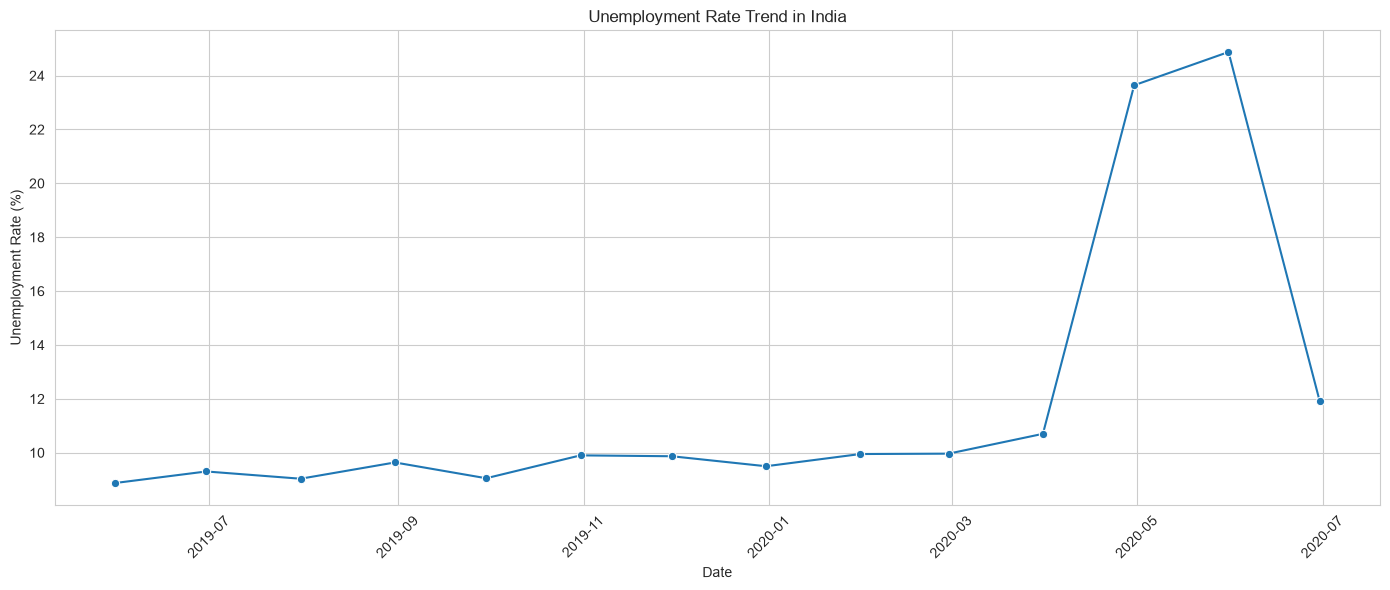

In [23]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_unemployment,
    x="Date",
    y="Estimated Unemployment Rate (%)",
    marker="o"
)

plt.title("Unemployment Rate Trend in India")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
df["COVID_Period"] = np.where(
    df["Date"] < "2020-03-01",
    "Pre-COVID",
    "COVID Period"
)

In [25]:
covid_analysis = (
    df.groupby("COVID_Period")
    ["Estimated Unemployment Rate (%)"]
    .mean()
)

print(covid_analysis)

COVID_Period
COVID Period    17.774363
Pre-COVID        9.509534
Name: Estimated Unemployment Rate (%), dtype: float64


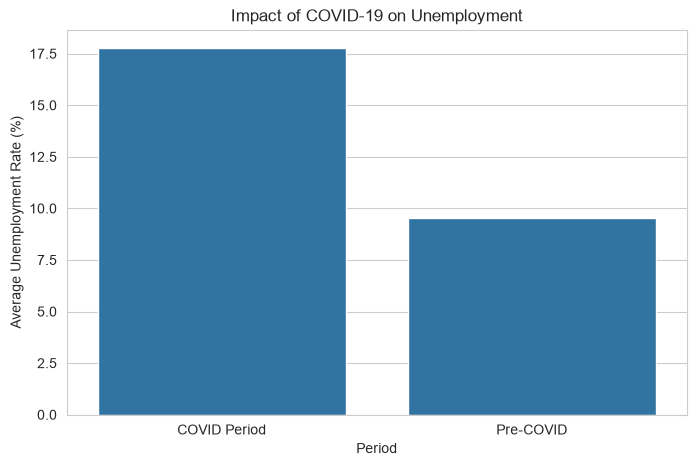

In [26]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=covid_analysis.index,
    y=covid_analysis.values
)

plt.title("Impact of COVID-19 on Unemployment")
plt.xlabel("Period")
plt.ylabel("Average Unemployment Rate (%)")

plt.show()

In [27]:
region_unemployment = (
    df.groupby("Region")
    ["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
)

print(region_unemployment)

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64


In [28]:
print(region_unemployment.head(10))

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Estimated Unemployment Rate (%), dtype: float64


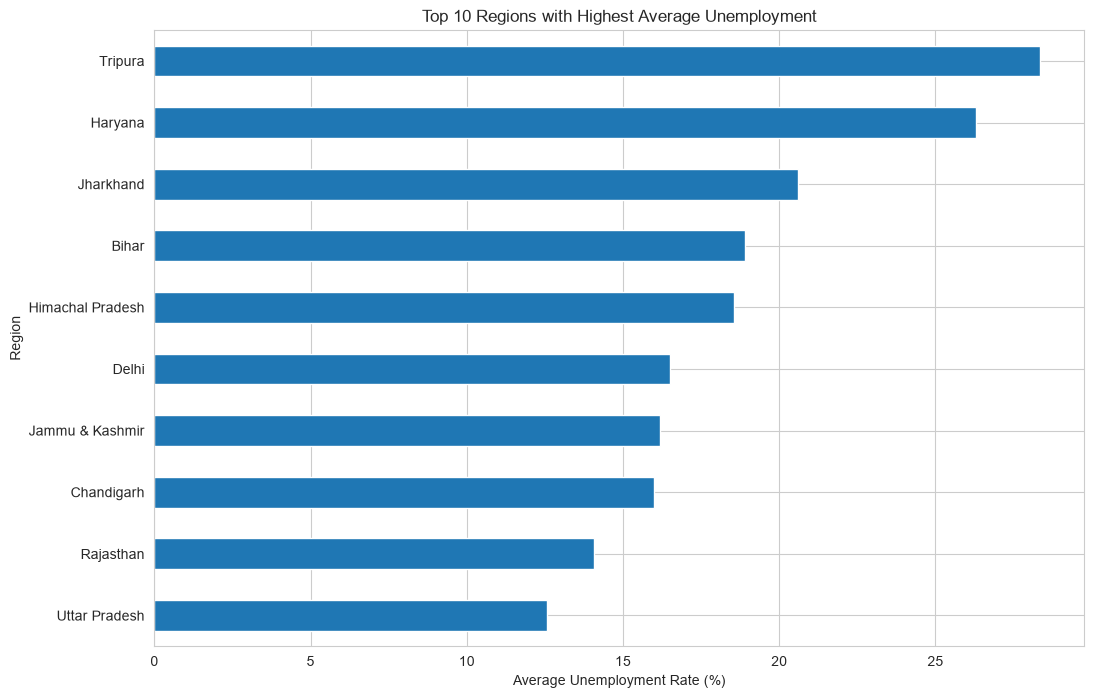

In [29]:
plt.figure(figsize=(12, 8))

region_unemployment.head(10).sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Regions with Highest Average Unemployment")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Region")

plt.show()

In [30]:
area_analysis = (
    df.groupby("Area")
    ["Estimated Unemployment Rate (%)"]
    .mean()
)

print(area_analysis)

Area
Rural    10.324791
Urban    13.166614
Name: Estimated Unemployment Rate (%), dtype: float64


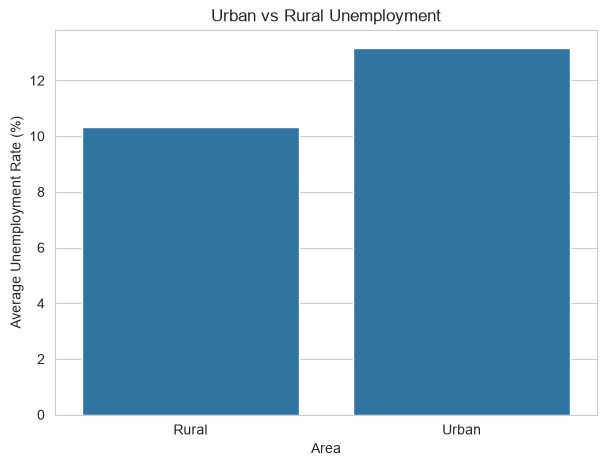

In [31]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=area_analysis.index,
    y=area_analysis.values
)

plt.title("Urban vs Rural Unemployment")
plt.xlabel("Area")
plt.ylabel("Average Unemployment Rate (%)")

plt.show()

In [32]:
month_order = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

monthly_pattern = (
    df.groupby("Month_Name")
    ["Estimated Unemployment Rate (%)"]
    .mean()
    .reindex(month_order)
)

print(monthly_pattern)

Month_Name
Jan     9.950755
Feb     9.964717
Mar    10.700577
Apr    23.641569
May    16.646190
Jun    10.553462
Jul     9.033889
Aug     9.637925
Sep     9.051731
Oct     9.900909
Nov     9.868364
Dec     9.497358
Name: Estimated Unemployment Rate (%), dtype: float64


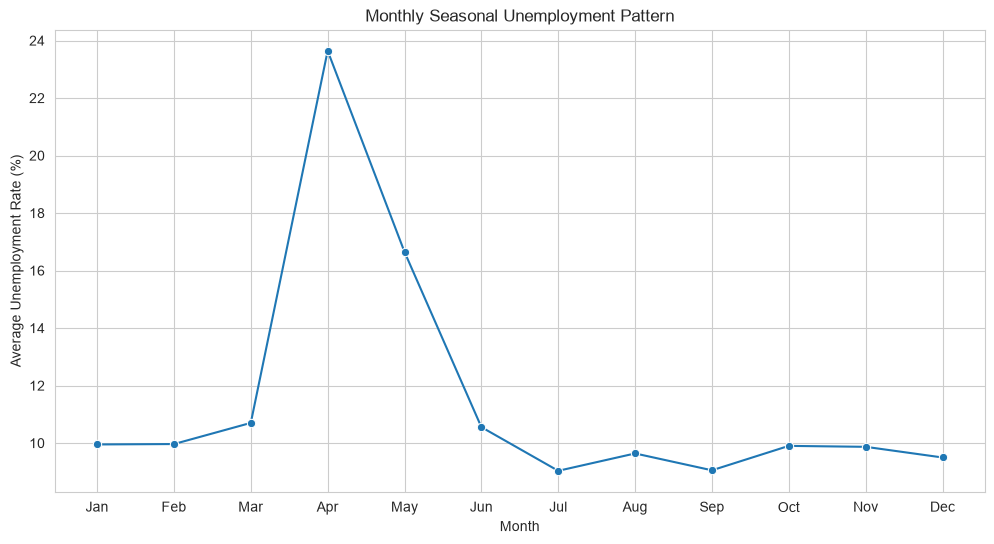

In [33]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    x=monthly_pattern.index,
    y=monthly_pattern.values,
    marker="o"
)

plt.title("Monthly Seasonal Unemployment Pattern")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")

plt.show()

In [34]:
numeric_columns = [
    "Estimated Unemployment Rate (%)",
    "Estimated Employed",
    "Estimated Labour Participation Rate (%)"
]

correlation = df[numeric_columns].corr()

print(correlation)

                                         Estimated Unemployment Rate (%)  \
Estimated Unemployment Rate (%)                                 1.000000   
Estimated Employed                                             -0.222876   
Estimated Labour Participation Rate (%)                         0.002558   

                                         Estimated Employed  \
Estimated Unemployment Rate (%)                   -0.222876   
Estimated Employed                                 1.000000   
Estimated Labour Participation Rate (%)            0.011300   

                                         Estimated Labour Participation Rate (%)  
Estimated Unemployment Rate (%)                                         0.002558  
Estimated Employed                                                      0.011300  
Estimated Labour Participation Rate (%)                                 1.000000  


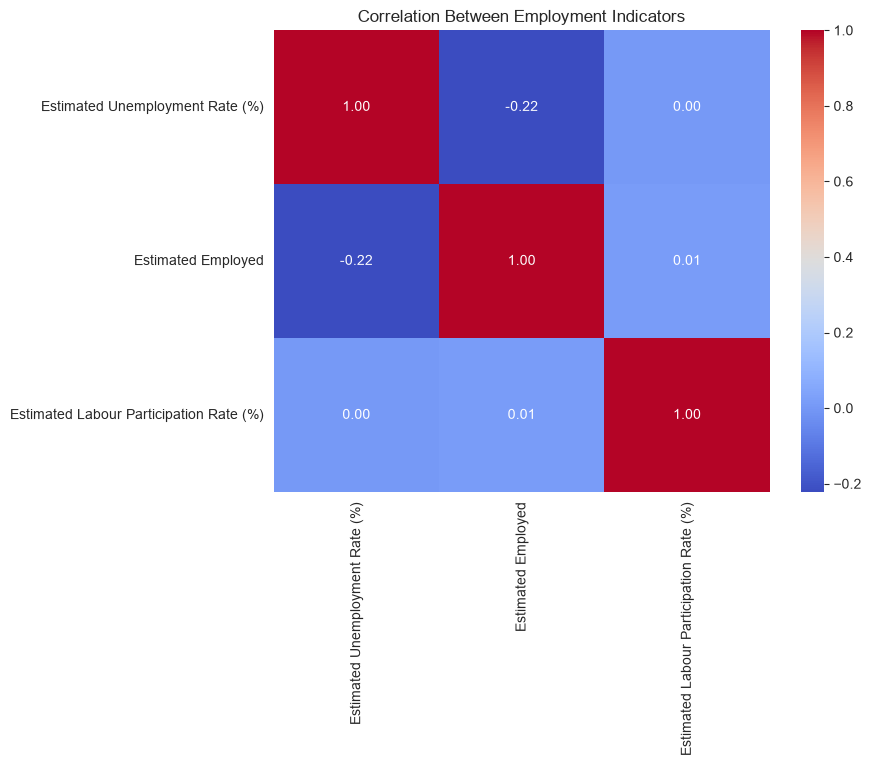

In [35]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Employment Indicators")

plt.show()

Key Findings
1. COVID-19 caused a major increase in unemployment

The average unemployment rate increased from approximately:

9.51% before COVID-19

to:

17.77% during the COVID period
2. April 2020 was the most severely affected period

The unemployment rate increased sharply during April 2020 because of:

Nationwide lockdowns
Business closures
Restrictions on transportation
Factory shutdowns
Loss of informal employment
3. Urban unemployment was higher than rural unemployment

The average unemployment rate was approximately:

Urban: 13.17%
Rural: 10.32%
4. Unemployment differed significantly across regions

Some regions consistently experienced higher unemployment than others.

This suggests that employment policies should be designed according to regional economic conditions.

5. A clear seasonal/time pattern was visible

Unemployment remained relatively stable before COVID-19, but rose sharply in:

March → April 2020

and then began declining:

April → May → June 2020

Policy Recommendations

Based on the analysis, the following policies could help reduce unemployment:

Employment Support

Governments can provide employment programs during economic crises.

Support for Small Businesses

Small businesses and industries should receive financial support to prevent large-scale layoffs.

Skill Development

Training programs can help unemployed people move into new industries.

Urban Employment Programs

Since urban unemployment was relatively high, special employment schemes could target cities.

Crisis Preparedness

Future pandemic or economic crisis plans should include:

Emergency unemployment benefits
Job protection schemes
Support for migrant workers
Digital employment platforms
Remote work opportunities

This analysis demonstrates how Python, Pandas, Matplotlib, and Seaborn can be used to clean, explore, and visualize unemployment data.

The most important conclusion is that COVID-19 had a dramatic impact on unemployment in India, particularly during the lockdown period in April 2020. The analysis also reveals differences between regions and rural/urban areas, providing useful information for economic planning and employment policy decisions.